In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openrouter import ChatOpenRouter
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

In [3]:
load_dotenv()
llm = ChatOpenRouter(model='nvidia/nemotron-3-ultra-550b-a55b:free')

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [5]:
def genrate_joke(state: JokeState):

    prompt = f'genrate a joke on the topic{state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [6]:
def genrate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

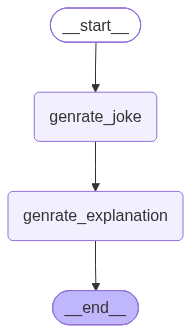

In [9]:
graph = StateGraph(JokeState)

graph.add_node('genrate_joke',genrate_joke)
graph.add_node('genrate_explanation',genrate_explanation)

graph.add_edge(START,'genrate_joke')
graph.add_edge('genrate_joke','genrate_explanation')
graph.add_edge('genrate_explanation',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [14]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic': 'marriage'},config=config1)

{'topic': 'marriage',
 'joke': 'Marriage is like a deck of cards.\n\nIn the beginning, all you need is **two hearts** and a **diamond**.\n\nBy the end, you’re looking for a **club** and a **spade**.',
 'explanation': 'Here is the breakdown of the joke:\n\n### The Core Mechanism: **Double Entendre (Puns on Card Suits)**\nThe humor relies entirely on the four suits in a standard deck of playing cards having **literal meanings** in the context of the game, but **metaphorical/slang meanings** in the context of a relationship.\n\n---\n\n### Part 1: "In the beginning, all you need is **two hearts** and a **diamond**."\n**The Romantic Interpretation (The Setup):**\n*   **Two Hearts:** Represents **love, affection, and emotional connection** between the two partners. "Hearts" is the universal symbol for romance.\n*   **A Diamond:** Represents the **engagement ring** (traditionally a diamond solitaire). It symbolizes commitment, wealth, value, and the "sparkle" of a new proposal.\n\n**The Vibe:

In [15]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'marriage', 'joke': 'Marriage is like a deck of cards.\n\nIn the beginning, all you need is **two hearts** and a **diamond**.\n\nBy the end, you’re looking for a **club** and a **spade**.', 'explanation': 'Here is the breakdown of the joke:\n\n### The Core Mechanism: **Double Entendre (Puns on Card Suits)**\nThe humor relies entirely on the four suits in a standard deck of playing cards having **literal meanings** in the context of the game, but **metaphorical/slang meanings** in the context of a relationship.\n\n---\n\n### Part 1: "In the beginning, all you need is **two hearts** and a **diamond**."\n**The Romantic Interpretation (The Setup):**\n*   **Two Hearts:** Represents **love, affection, and emotional connection** between the two partners. "Hearts" is the universal symbol for romance.\n*   **A Diamond:** Represents the **engagement ring** (traditionally a diamond solitaire). It symbolizes commitment, wealth, value, and the "sparkle" of a new propo

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'marriage', 'joke': 'Marriage is like a deck of cards.\n\nIn the beginning, all you need is **two hearts** and a **diamond**.\n\nBy the end, you’re looking for a **club** and a **spade**.', 'explanation': 'Here is the breakdown of the joke:\n\n### The Core Mechanism: **Double Entendre (Puns on Card Suits)**\nThe humor relies entirely on the four suits in a standard deck of playing cards having **literal meanings** in the context of the game, but **metaphorical/slang meanings** in the context of a relationship.\n\n---\n\n### Part 1: "In the beginning, all you need is **two hearts** and a **diamond**."\n**The Romantic Interpretation (The Setup):**\n*   **Two Hearts:** Represents **love, affection, and emotional connection** between the two partners. "Hearts" is the universal symbol for romance.\n*   **A Diamond:** Represents the **engagement ring** (traditionally a diamond solitaire). It symbolizes commitment, wealth, value, and the "sparkle" of a new prop

In [18]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'school'},config=config2)

{'topic': 'school',
 'joke': '**Teacher:** "If all your friends jumped off a bridge, would you do it too?"\n\n**Student:** "That depends... is it a group project? Because if it is, I\'m doing all the work *and* jumping off the bridge by myself."',
 'explanation': '**The Core Conflict: Parental Logic vs. Academic Reality**\n\nThis joke works by subverting the classic rhetorical trap parents and teachers use to teach **independent thinking and resistance to peer pressure**.\n\n### 1. The Setup (The "Bridge" Trope)\n**Teacher:** *"If all your friends jumped off a bridge, would you do it too?"*\n*   **Standard Meaning:** This is a metaphor for "blind conformity." The expected answer is **"No."** The lesson: Think for yourself; don\'t do something stupid/dangerous just because everyone else is doing it.\n*   **The Trap:** The teacher expects the student to assert their individuality and moral courage.\n\n### 2. The Pivot (The "Group Project" Condition)\n**Student:** *"That depends... is it 

In [19]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'school', 'joke': '**Teacher:** "If all your friends jumped off a bridge, would you do it too?"\n\n**Student:** "That depends... is it a group project? Because if it is, I\'m doing all the work *and* jumping off the bridge by myself."', 'explanation': '**The Core Conflict: Parental Logic vs. Academic Reality**\n\nThis joke works by subverting the classic rhetorical trap parents and teachers use to teach **independent thinking and resistance to peer pressure**.\n\n### 1. The Setup (The "Bridge" Trope)\n**Teacher:** *"If all your friends jumped off a bridge, would you do it too?"*\n*   **Standard Meaning:** This is a metaphor for "blind conformity." The expected answer is **"No."** The lesson: Think for yourself; don\'t do something stupid/dangerous just because everyone else is doing it.\n*   **The Trap:** The teacher expects the student to assert their individuality and moral courage.\n\n### 2. The Pivot (The "Group Project" Condition)\n**Student:** *"Tha

In [20]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'school', 'joke': '**Teacher:** "If all your friends jumped off a bridge, would you do it too?"\n\n**Student:** "That depends... is it a group project? Because if it is, I\'m doing all the work *and* jumping off the bridge by myself."', 'explanation': '**The Core Conflict: Parental Logic vs. Academic Reality**\n\nThis joke works by subverting the classic rhetorical trap parents and teachers use to teach **independent thinking and resistance to peer pressure**.\n\n### 1. The Setup (The "Bridge" Trope)\n**Teacher:** *"If all your friends jumped off a bridge, would you do it too?"*\n*   **Standard Meaning:** This is a metaphor for "blind conformity." The expected answer is **"No."** The lesson: Think for yourself; don\'t do something stupid/dangerous just because everyone else is doing it.\n*   **The Trap:** The teacher expects the student to assert their individuality and moral courage.\n\n### 2. The Pivot (The "Group Project" Condition)\n**Student:** *"Th

Time Travel

In [21]:
workflow.get_state({"configurable": {"thread_id": "1", 'checkpoint_id': '1f194af5-8057-6264-bfff-e9398c9f6272'}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f194af5-8057-6264-bfff-e9398c9f6272'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())